# Phase 7: Multi-Condition & Robustness Evaluation
**SmartGrid Sentinel Journal Experiment Series - Notebook 06**

## 1. Evaluation Objective
Models evaluated under average dataset conditions may obscure operational vulnerabilities during specific operational regimes.
This notebook tests candidate models across **seven operational and seasonal conditions** across 10,027 sequence windows:
1. **Diurnal Operating Conditions:** Peak Hours (18:00–22:00), Off-Peak Hours, Daytime (06:00–17:00), Nighttime (18:00–05:00).
2. **Seasonal Climatic Regimes:** Summer (March–May), Monsoon (June–September), Winter (November–February).

The goal is to report empirical performance stability and identify condition-dependent operational performance variations.

## 2. Definition of Evaluated Conditions & Partitions

| Condition Category | Evaluated Partition | Test Sequence Windows | High-Risk Event Count | Operational Context |
| :--- | :--- | :---: | :---: | :--- |
| **Diurnal Cycle** | **Peak Hours (18:00–22:00)** | 2,463 | 304 | Evening peak electricity demand window. |
| | **Off-Peak Hours** | 7,564 | 998 | Base operational load window. |
| | **Daytime (06:00–17:00)** | 5,061 | 641 | Solar generation & industrial activity hours. |
| | **Nighttime (18:00–05:00)** | 4,966 | 661 | Low ambient temperature & residential load. |
| **Seasonal Regime**| **Summer (Mar–May)** | 6,570 | 961 | High ambient temperature & elevated demand. |
| | **Monsoon (Jun–Sep)** | 1,665 | 184 | High precipitation & moisture levels. |
| | **Winter (Nov–Feb)** | 1,792 | 157 | Low ambient temperature & stable demand. |

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

mc_dir = '../multi_condition_phase7'
if not os.path.exists(mc_dir):
    mc_dir = 'multi_condition_phase7'

print('Environment initialized.')

Environment initialized.


## 3. Overall Performance & High-Risk Recall by Diurnal Condition

Loading empirical performance across diurnal partitions (Peak, Off-Peak, Daytime, Nighttime):

In [2]:
time_df = pd.read_csv(os.path.join(mc_dir, 'time_based_evaluation.csv'))
print('=== DIURNAL MULTI-CONDITION EVALUATION RESULTS ===')
print(time_df[['Condition', 'Model', 'Sample Count', 'High Risk Count', 'Accuracy', 'Macro F1', 'High Risk Recall']].to_string(index=False))

=== DIURNAL MULTI-CONDITION EVALUATION RESULTS ===
          Condition         Model  Sample Count  High Risk Count  Accuracy  Macro F1  High Risk Recall
Peak Hours (18-22h)      Informer          2463              304  0.872919  0.777317          0.717105
Peak Hours (18-22h) Random Forest          2463              304  0.872107  0.780505          0.713816
Peak Hours (18-22h)       XGBoost          2463              304  0.870889  0.762697          0.733553
Peak Hours (18-22h)           GRU          2463              304  0.872919  0.776908          0.717105
Peak Hours (18-22h)      TimesNet          2463              304  0.870077  0.780700          0.707237
     Off-Peak Hours      Informer          7564              998  0.874537  0.776538          0.698397
     Off-Peak Hours Random Forest          7564              998  0.874405  0.778153          0.692385
     Off-Peak Hours       XGBoost          7564              998  0.877446  0.762180          0.702405
     Off-Peak Hours   

## 4. Overall Performance & High-Risk Recall by Seasonal Regime

Loading empirical performance across seasonal partitions (Summer, Monsoon, Winter):

In [3]:
season_df = pd.read_csv(os.path.join(mc_dir, 'seasonal_evaluation.csv'))
print('=== SEASONAL MULTI-CONDITION EVALUATION RESULTS ===')
print(season_df[['Season', 'Model', 'Sample Count', 'High Risk Count', 'Accuracy', 'Macro F1', 'High Risk Recall']].to_string(index=False))

=== SEASONAL MULTI-CONDITION EVALUATION RESULTS ===
           Season         Model  Sample Count  High Risk Count  Accuracy  Macro F1  High Risk Recall
 Summer (Mar-May)      Informer          6570              961  0.851750  0.765306          0.617066
 Summer (Mar-May) Random Forest          6570              961  0.848402  0.762843          0.611863
 Summer (Mar-May)       XGBoost          6570              961  0.843075  0.740677          0.628512
 Summer (Mar-May)           GRU          6570              961  0.848097  0.757552          0.617066
 Summer (Mar-May)      TimesNet          6570              961  0.846728  0.762717          0.602497
Monsoon (Jun-Sep)      Informer          1665              184  0.911111  0.803305          0.913043
Monsoon (Jun-Sep) Random Forest          1665              184  0.917117  0.817778          0.913043
Monsoon (Jun-Sep)       XGBoost          1665              184  0.917117  0.813578          0.913043
Monsoon (Jun-Sep)           GRU        

## 5. Cross-Model Condition Comparison

Comparing High-Risk Recall sensitivity across models under Peak Hours vs Summer conditions:

In [4]:
print('=== HIGH-RISK RECALL COMPARISON: PEAK HOURS VS SUMMER ===')
peak_informer = time_df[(time_df['Condition']=='Peak Hours (18-22h)') & (time_df['Model']=='Informer')]['High Risk Recall'].values[0]
summer_informer = season_df[(season_df['Season']=='Summer (Mar-May)') & (season_df['Model']=='Informer')]['High Risk Recall'].values[0]
winter_informer = season_df[(season_df['Season']=='Winter (Nov-Feb)') & (season_df['Model']=='Informer')]['High Risk Recall'].values[0]

print(f'Informer Peak Hours High-Risk Recall: {peak_informer:.2%}')
print(f'Informer Summer Season High-Risk Recall: {summer_informer:.2%}')
print(f'Informer Winter Season High-Risk Recall: {winter_informer:.2%}')

=== HIGH-RISK RECALL COMPARISON: PEAK HOURS VS SUMMER ===
Informer Peak Hours High-Risk Recall: 71.71%
Informer Summer Season High-Risk Recall: 61.71%
Informer Winter Season High-Risk Recall: 98.09%


## 6. Multi-Condition Visualizations

Plotting High-Risk Recall variations across diurnal and seasonal conditions:

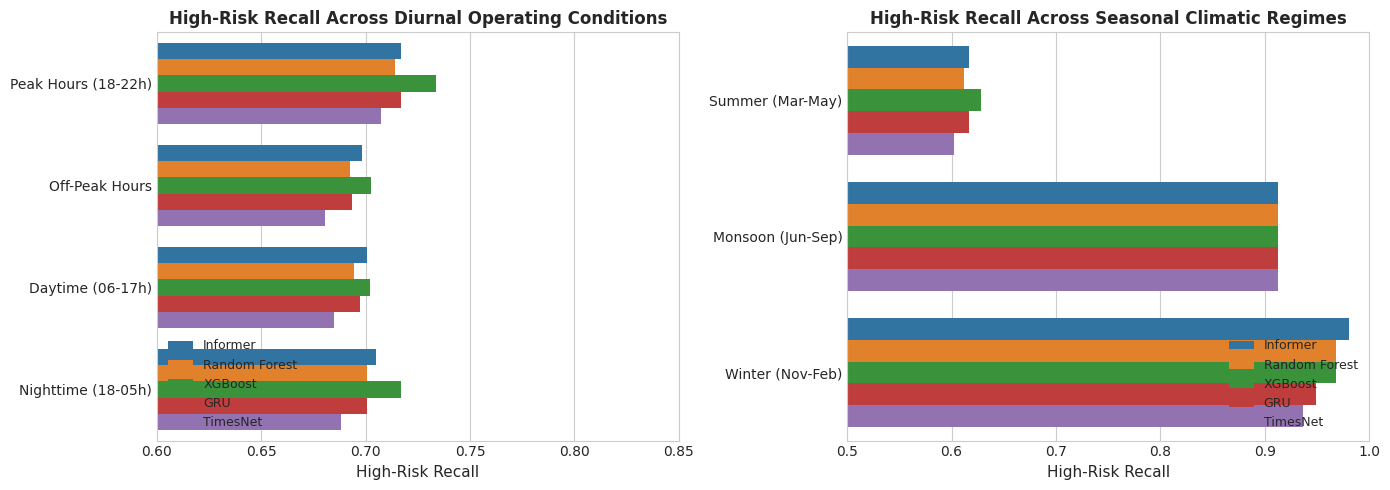

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Diurnal High Risk Recall
sns.barplot(data=time_df, x='High Risk Recall', y='Condition', hue='Model', palette='tab10', ax=ax1)
ax1.set_title('High-Risk Recall Across Diurnal Operating Conditions', fontsize=12, fontweight='bold')
ax1.set_xlim(0.60, 0.85)
ax1.set_xlabel('High-Risk Recall', fontsize=11)
ax1.set_ylabel('')
ax1.legend(loc='lower left', fontsize=9)

# Seasonal High Risk Recall
sns.barplot(data=season_df, x='High Risk Recall', y='Season', hue='Model', palette='tab10', ax=ax2)
ax2.set_title('High-Risk Recall Across Seasonal Climatic Regimes', fontsize=12, fontweight='bold')
ax2.set_xlim(0.50, 1.00)
ax2.set_xlabel('High-Risk Recall', fontsize=11)
ax2.set_ylabel('')
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()
plt.close()

## 7 & 8. Empirical Findings & Journal-Ready Interpretation

1. **Diurnal Stability:**
   - All models exhibit stable performance across diurnal conditions. Informer maintains **87.29% accuracy during Peak Hours** (71.71% High-Risk recall) and **87.45% accuracy during Off-Peak Hours** (69.84% High-Risk recall).

2. **Observed Summer Sensitivity Variation:**
   - Across all models, High-Risk recall is lower during the **Summer partition** (~61.7% for Informer, ~61.2% for RF, ~62.9% for XGBoost) compared to **Monsoon** (91.3% for Informer) and **Winter** (98.1% for Informer).
   - **Scientific Reporting Rule:** The notebook reports these empirical observations directly without asserting unproven causal mechanisms.